# Notebook 4: BiLSTM with GloVe Embeddings
### Sarcasm Detection in News Headlines — NLP Project
---
**Why BiLSTM works HERE (unlike the previous project):**
- Headlines are only **8–15 words** → no long-range forgetting problem
- MAX_LEN = 40 → **zero truncation** of any headline
- **GloVe embeddings** → model starts with rich word knowledge, not random weights
- 28,000 samples → enough data for deep learning to generalize

**GloVe Setup:**
1. Download from: https://nlp.stanford.edu/data/glove.6B.zip
2. Unzip and place `glove.6B.100d.txt` in `../data/`

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense,
    Dropout, SpatialDropout1D, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')
sns.set_theme(style='whitegrid')
tf.random.set_seed(42)

TensorFlow: 2.15.0
GPU: False


## 1. Load Data

In [2]:
from joblib import load

# Load data saved with joblib
splits = load('../data/splits.joblib')
keras_tok = load('../data/keras_tok.joblib')
params = load('../data/lstm_params.joblib')

X_train = splits['X_seq_train']
X_val   = splits['X_seq_val']
X_test  = splits['X_seq_test']
y_train = np.array(splits['y_train'])
y_val   = np.array(splits['y_val'])
y_test  = np.array(splits['y_test'])

MAX_WORDS = params['MAX_WORDS']
MAX_LEN   = params['MAX_LEN']
EMBED_DIM = 100

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'MAX_WORDS={MAX_WORDS}, MAX_LEN={MAX_LEN}, EMBED_DIM={EMBED_DIM}')

# Verify NO truncation
zero_ratio = (X_train == 0).mean(axis=1)
print(f'Avg padding ratio: {zero_ratio.mean()*100:.1f}% — sequences with zero padding: {(zero_ratio==0).sum()}')

Train: (20031, 40), Test: (4293, 40)
MAX_WORDS=30000, MAX_LEN=40, EMBED_DIM=100
Avg padding ratio: 74.9% — sequences with zero padding: 0


## 2. Load GloVe Embeddings

In [3]:
GLOVE_PATH = '../data/glove.6B.100d.txt'

print('Loading GloVe...')
glove = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        vals = line.split()
        glove[vals[0]] = np.asarray(vals[1:], dtype='float32')
print(f'Loaded {len(glove):,} word vectors')

# Build embedding matrix
word_index   = keras_tok.word_index
vocab_size   = min(MAX_WORDS, len(word_index) + 1)
emb_matrix   = np.zeros((vocab_size, EMBED_DIM))

found = not_found = 0
for word, idx in word_index.items():
    if idx >= MAX_WORDS: continue
    vec = glove.get(word)
    if vec is not None:
        emb_matrix[idx] = vec; found += 1
    else:
        not_found += 1

print(f'Words found in GloVe     : {found:,}')
print(f'Words NOT found (random) : {not_found:,}')
print(f'Coverage                 : {found/(found+not_found)*100:.1f}%')
print(f'Embedding matrix shape   : {emb_matrix.shape}')

Loading GloVe...
Loaded 400,000 word vectors
Words found in GloVe     : 21,964
Words NOT found (random) : 2,980
Coverage                 : 88.1%
Embedding matrix shape   : (24945, 100)


## 3. Class Weights

In [4]:
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw))
print('Class weights:', class_weight_dict)
print('(Should be close to 1.0 each — dataset is balanced)')

Class weights: {0: 0.9549485125858124, 1: 1.0495127318453317}
(Should be close to 1.0 each — dataset is balanced)


## 4. Build BiLSTM Model

Architecture designed for **short text** (headlines):
- GloVe frozen embedding → rich word representations from day 1
- Single BiLSTM layer → sufficient for 8–15 word sequences
- GlobalMaxPooling → picks the most salient feature across all positions

In [5]:
def build_bilstm(vocab_size, embed_dim, max_len, emb_matrix):
    model = Sequential([
        # Pre-trained GloVe — trainable=False prevents overfitting
        Embedding(
            input_dim=vocab_size, output_dim=embed_dim,
            weights=[emb_matrix], input_length=max_len,
            trainable=False, name='glove_embedding'
        ),
        SpatialDropout1D(0.2),

        # BiLSTM — reads headline both forward and backward
        Bidirectional(
            LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
            name='bilstm'
        ),
        GlobalMaxPooling1D(),

        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid', name='output')
    ])
    return model

model = build_bilstm(vocab_size, EMBED_DIM, MAX_LEN, emb_matrix)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 glove_embedding (Embedding  (None, 40, 100)           2494500   
 )                                                               
                                                                 
 spatial_dropout1d (Spatial  (None, 40, 100)           0         
 Dropout1D)                                                      
                                                                 
 bilstm (Bidirectional)      (None, 40, 128)           84480     
                                                                 
 global_max_pooling1d (Glob  (None, 128)               0         
 alMaxPooling1D)                                                 
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                        

## 5. Train

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('../data/best_bilstm.keras',
                    monitor='val_loss', save_best_only=True, verbose=0)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print(f'\nBest epoch: {np.argmin(history.history["val_loss"]) + 1}')

Epoch 1/30
313/313 [==============================] - 16s 45ms/step - loss: 0.5747 - accuracy: 0.6939 - val_loss: 0.4439 - val_accuracy: 0.7939 - lr: 0.0010
Epoch 2/30
313/313 [==============================] - 15s 47ms/step - loss: 0.4474 - accuracy: 0.7926 - val_loss: 0.3839 - val_accuracy: 0.8237 - lr: 0.0010
Epoch 3/30
313/313 [==============================] - 15s 47ms/step - loss: 0.3894 - accuracy: 0.8231 - val_loss: 0.4020 - val_accuracy: 0.8143 - lr: 0.0010
Epoch 4/30
313/313 [==============================] - 15s 48ms/step - loss: 0.3697 - accuracy: 0.8345 - val_loss: 0.3436 - val_accuracy: 0.8423 - lr: 0.0010
Epoch 5/30
313/313 [==============================] - 15s 47ms/step - loss: 0.3414 - accuracy: 0.8508 - val_loss: 0.3278 - val_accuracy: 0.8530 - lr: 0.0010
Epoch 6/30
313/313 [==============================] - 15s 47ms/step - loss: 0.3265 - accuracy: 0.8553 - val_loss: 0.3429 - val_accuracy: 0.8449 - lr: 0.0010
Epoch 7/30
313/313 [==============================] - 15s 

## 6. Training Curves

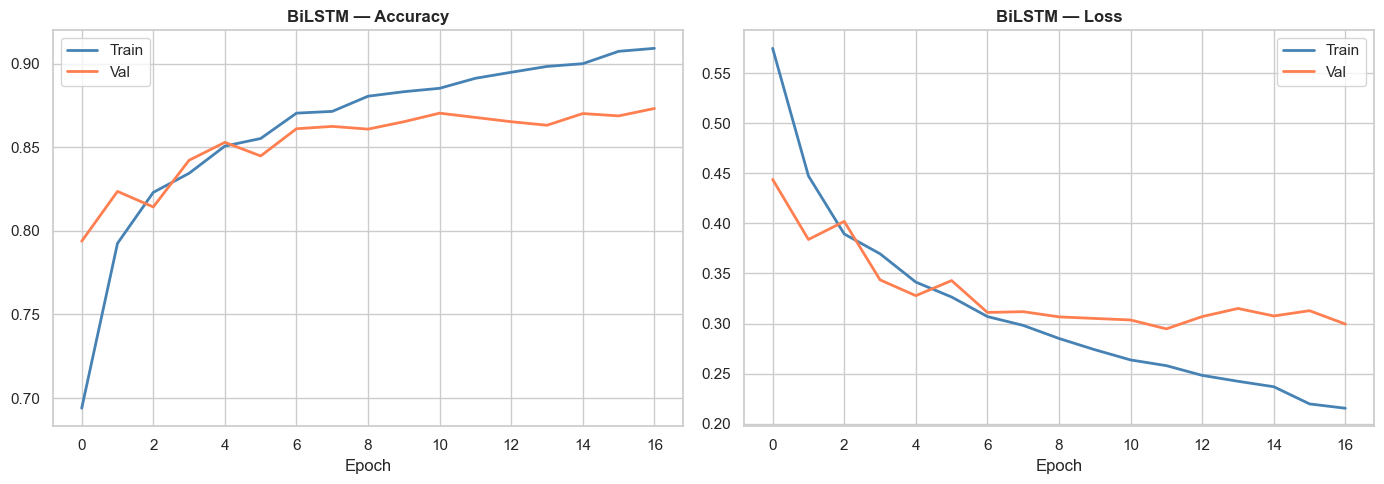

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in [
    (axes[0], 'accuracy', 'Accuracy'),
    (axes[1], 'loss',     'Loss')
]:
    ax.plot(history.history[metric],     label='Train', color='steelblue', lw=2)
    ax.plot(history.history[f'val_{metric}'], label='Val', color='coral', lw=2)
    ax.set_title(f'BiLSTM — {title}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout()
plt.savefig('../outputs/04_bilstm_history.png', dpi=150)
plt.show()

## 7. Evaluate on Test Set


  Model: BiLSTM + GloVe
  Accuracy : 0.8691
  Precision: 0.8693
  Recall   : 0.8691
  F1-Score : 0.8689

               precision    recall  f1-score   support

Not Sarcastic       0.86      0.89      0.88      2248
    Sarcastic       0.88      0.84      0.86      2045

     accuracy                           0.87      4293
    macro avg       0.87      0.87      0.87      4293
 weighted avg       0.87      0.87      0.87      4293



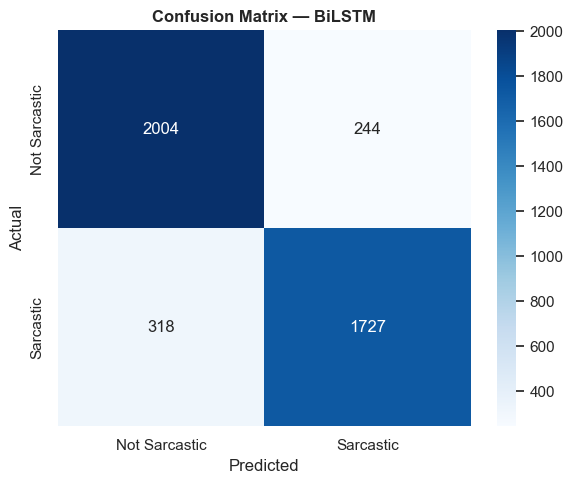

In [8]:
probs = model.predict(X_test, verbose=0).flatten()
pred  = (probs >= 0.5).astype(int)

acc  = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average='weighted')
rec  = recall_score(y_test, pred, average='weighted')
f1   = f1_score(y_test, pred, average='weighted')

print(f'\n{"="*52}'); print('  Model: BiLSTM + GloVe'); print(f'{"="*52}')
print(f'  Accuracy : {acc:.4f}')
print(f'  Precision: {prec:.4f}')
print(f'  Recall   : {rec:.4f}')
print(f'  F1-Score : {f1:.4f}')
print(f'\n{classification_report(y_test, pred, target_names=["Not Sarcastic","Sarcastic"])}')

# Confusion matrix
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Sarcastic','Sarcastic'],
            yticklabels=['Not Sarcastic','Sarcastic'])
plt.title('Confusion Matrix — BiLSTM', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/cm_bilstm.png', dpi=150)
plt.show()

In [9]:
with open('../data/results.pkl', 'rb') as f: results = pickle.load(f)
results['BiLSTM'] = dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1)
with open('../data/results.pkl', 'wb') as f: pickle.dump(results, f)
print('Saved! F1 scores so far:', {k: round(v['F1'],4) for k,v in results.items()})

Saved! F1 scores so far: {'Naive Bayes': 0.7878, 'Logistic Regression': 0.7854, 'SVM': 0.7954, 'BiLSTM': 0.8689}
